# Crossreads Petrography: pXRF Processing

In [1]:
import sys; sys.path.append('..')
from crossreads_petrography.pxrf import *

Using user-specific config file: /Users/ryan/crossreads_petrography_data/config.yaml @ 2024-08-26 19:00:46,685
Initializing Config with yaml_path: /Users/ryan/crossreads_petrography_data/config.yaml @ 2024-08-26 19:00:46,685
Loading config from /Users/ryan/crossreads_petrography_data/config.yaml @ 2024-08-26 19:00:46,685
Config loaded and processed successfully @ 2024-08-26 19:00:46,690


In [2]:
xrf = PXRFConverter()
xrf

Initializing PXRFConverter @ 2024-08-26 19:00:46,699


## Descriptions

This file lives on Google Drive on the Crossreads team drive. It contains notes about the samples, including the Isic codes.

In [3]:
pd.options.display.max_columns = 1000
xrf.df_descriptions

Loading pXRF descriptions @ 2024-08-26 19:00:46,707


,instrument,site,day,month,year,cass,inv/id,Isic,count analyses,a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y,z
0,demo-MK,salinas,,10,2022,museo,,Isic000004,6,"wh, between r n, L 1","wh, between f g, L 1","wh, end of L 3, diagonal","gr, x e, L 2","gr, inside first m of m m, L 1","between fe c, L 4",,,,,,,,,,,,,,,,,,,,
1,demo-MK,termini imerese,,3,2023,depositi,,Isic000086,9,"yellow, v","yellow, back","yellow, back","pink, back","pink, back","pink, below I","rosso, edge","rosso, back, edge","rosso, vein",,,,,,,,,,,,,,,,,
2,demo-MK,termini imerese,,3,2023,museo,,Isic000092,6,"O, L 1","Q, L 1","O, L 1",sample,sample,sample,,,,,,,,,,,,,,,,,,,,
3,demo-MK,termini imerese,,3,2023,museo,,Isic000095,15,yellow,yellow,yellow,orange below GIO,orange below GIO,orange o in PO,dark pink vein,dark pink vein,"dark pink vein, right side","pink, above NP","pink, centre frame","pink, above EN","red, sample","red, sample","red, sample",,,,,,,,,,,
4,demo-MK,termini imerese,,3,2023,museo,,Isic000097,3,"above roc, L 5","between iv praef, L 6","E, L 5",,,,,,,,,,,,,,,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,demo-MK,taormina,22.0,1,2024,,torso,taorminatorso,4,under right armpit,left shoulder,right shoulder,"brown, hair",,,,,,,,,,,,,,,,,,,,,,
598,demo-MK,tindari,,7,2024,,TIND004,tindariTIND004,4,white,white,grey,grey,,,,,,,,,,,,,,,,,,,,,,
599,demo-MK,tindari,,7,2024,,TIND005,tindariTIND005,3,sample,sample,sample,,,,,,,,,,,,,,,,,,,,,,,
600,demo-MK,tindari,,7,2024,,TIND007,tindariTIND007,3,sample,sample,sample,,,,,,,,,,,,,,,,,,,,,,,


## Standards



In [4]:
xrf.df_standards

Loading pXRF standard values @ 2024-08-26 19:00:46,942


Unnamed: 0,0CC,10CC,20CC,30CC,40CC,50CC,60CC,70CC,80CC,90CC,100CC
Element,,,,,,,,,,,
SiO2,91.040645,84.721351,78.817028,73.795328,64.449734,55.454155,32.568351,27.167883,21.531343,11.572406,1.000000e-08
K2O,6.002285,5.585656,5.196385,4.865306,4.249153,3.656077,2.147222,1.791171,1.419556,0.762966,1.000000e-08
CaO,0.958449,7.880084,14.336479,19.820316,30.009677,39.799615,64.641336,70.491810,76.593960,87.366212,9.987017e+01
Fe2O3,1.998622,1.812909,1.650108,1.519050,1.291436,1.090152,0.643091,0.549136,0.455141,0.298417,1.298312e-01
Ba,120.000000,107.870481,97.275091,88.771005,74.055316,61.098357,32.508134,26.532239,20.565139,10.640721,0.000000e+00
Ce,195.000000,175.289532,158.072023,144.252883,120.339889,99.284830,52.825719,43.114889,33.418351,17.291171,0.000000e+00
Co,4.000000,3.595683,3.242503,2.959033,2.468511,2.036612,1.083604,0.884408,0.685505,0.354691,0.000000e+00
Cr,12.000000,10.787048,9.727509,8.877100,7.405532,6.109836,3.250813,2.653224,2.056514,1.064072,0.000000e+00
Fe,14261.000000,12890.263285,11692.895909,10731.863281,9068.867850,7604.623464,4373.690099,3698.364127,3024.032108,1902.490132,7.000000e+02


## pXRF input data

Two kinds of files:
* "MK" files
    * Filename must start with 
    * Only Si, K, Ca, and Fe are included
* "t" files
    * Filenames must start with "t"
    * All elements with linear correlation with standard values (plus HG) are included

pXRF input data is processed in `df_measurements_with_standard_values`, attaching relevant standard values if present from `df_standards`.

In [5]:
xrf.df_input

,filename,text
0,t tindari.txt,SOURCE: ISic000672-tK-a.csv\nKEY: 1.1.00001.1\...
1,MK taormina.txt,SOURCE: 0-1.csv\nKEY: 1.1.00001.1\nElement Gr...
2,t halaesa.txt,SOURCE: HAL18-tK-a.csv\nKEY: 1.1.00001.1\nElem...
3,MK termini.txt,SOURCE: 0-1.csv\nKEY: 1.1.00001.1\nElement Gr...
4,t exmft.txt,SOURCE: t0-10CC-1.csv\nKEY: 1.1.00001.1\nEleme...
5,t centuripe.txt,SOURCE: ISic000655-t-a.csv\nKEY: 1.1.00001.1\n...
6,t Hg test.txt,SOURCE: cass27-ISic000368-1t.csv\nKEY: 1.1.000...
7,MK tindari.txt,SOURCE: 0-1.csv\nKEY: 1.1.00001.1\nElement Gr...
8,t Hg test with standards.txt,SOURCE: KA0863-t-a.csv\nKEY: 1.1.00001.1\nElem...
9,MK centuripe.txt,SOURCE: 0-1.csv\nKEY: 1.1.00001.1\nElement Gr...


In [6]:
xrf.df_parsed

Parsing pXRF standards data @ 2024-08-26 19:00:46,987


,Group,Fit_Area,Sigma_Area,Mass_fraction,standard_val,standard_key,source_name,filename,standard_group
Element,,,,,,,,,
Al,K,1.369939e+02,3.79e+01,0.210300,NaN,NaN,NaN,t tindari.txt,(all)
Ar,K,3.840009e+02,5.50e+01,0.004590,NaN,NaN,NaN,t tindari.txt,(all)
As,K,4.739575e+02,8.93e+01,0.000142,NaN,NaN,NaN,t tindari.txt,(all)
Au,L,2.176277e+02,6.64e+01,0.000070,NaN,NaN,NaN,t tindari.txt,(all)
Ba,NaN,NaN,NaN,NaN,107.870481,10CC,t0-10CC-1,t tindari.txt,(all)
...,...,...,...,...,...,...,...,...,...
Ti,K,2.741946e+01,2.99e+01,0.000027,26.500000,100CC,t0-100CC-3,t termini.txt,(all)
V,NaN,NaN,NaN,NaN,0.000000,100CC,t0-100CC-3,t termini.txt,(all)
Y,K,5.072686e+02,8.10e+01,0.000067,0.000000,100CC,t0-100CC-3,t termini.txt,(all)


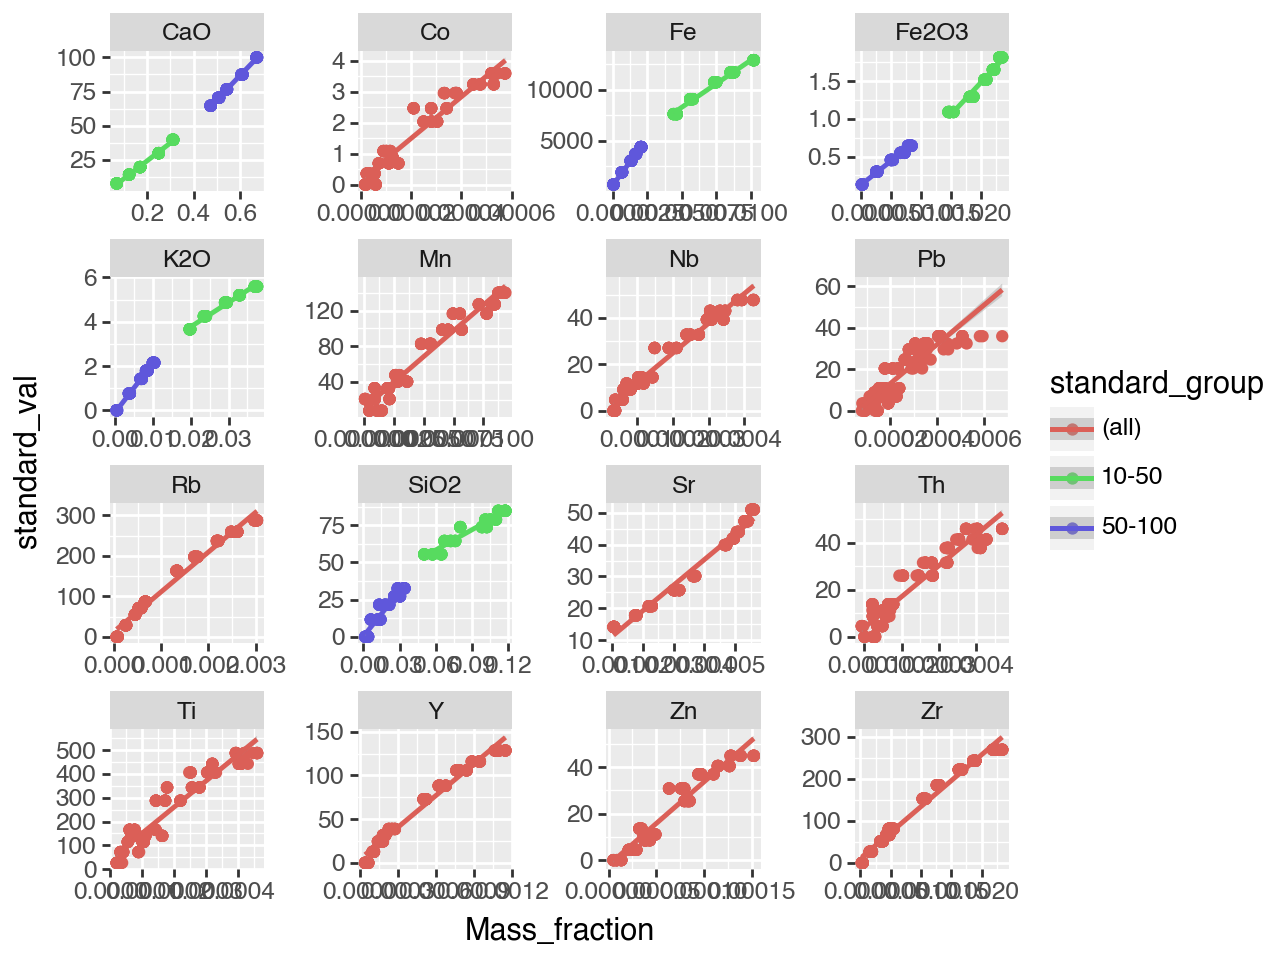

In [7]:
# Plotting mass fraction against standard values to find slope and intercept
xrf.plot()

In [8]:
# Finding mass fraction against standard values to find slope and intercept
# we add Hg to the list of elements by copying the slope and intercept from Pb
df=xrf.df_linreg
df

Calculating linear regressions for standard values @ 2024-08-26 19:00:49,741


,Element,standard_group,m,q
0,CaO,10-50,1.310280e+02,-1.954271
1,CaO,50-100,1.776364e+02,-19.710600
2,Co,(all),6.721652e+04,0.148092
3,Fe,10-50,9.218268e+05,3672.993990
4,Fe,50-100,1.829764e+06,666.703086
5,Fe2O3,10-50,8.520072e+01,-0.224070
6,Fe2O3,50-100,6.344065e+01,0.120536
7,K2O,10-50,1.097790e+02,1.572592
8,K2O,50-100,2.221348e+02,-0.103417
9,Mn,(all),1.154678e+06,10.777187


In [9]:
# Measurements with adjusted mass fraction values due to slope and intercept from regression
xrf.df_adjusted

Parsing pXRF measurements and calculating new fractions @ 2024-08-26 19:00:49,763


Group  Fit_Area  Sigma_Area  Mass_fraction  \
source_name     Element                                              
ISic000672-tK-a Ti          K     68.12        31.9            0.0   
                Mn          K     72.48        21.5            0.0   
                Co          K     33.01        19.2            0.0   
                Zn          K    245.93        23.7            0.0   
                Rb          K    282.44        66.0            0.0   
...                       ...       ...         ...            ...   
ISic003083-t-c  Zr          K    236.76        93.5            0.0   
                Nb          K    221.03        84.1            0.0   
                Hg          L    241.08        53.3            0.0   
                Pb          L   1115.42        69.7            0.0   
                Th          L    813.84       106.0            0.0   

                        standard_group           m      q       y  \
source_name     Element                                             
ISic000672-tK-a Ti               (all)  1096368.67  42.15  115.07   
                Mn               (all)  1154678.36  10.78   31.54   
                Co               (all)    67216.52   0.15    0.41   
                Zn               (all)   357890.62  -2.11   11.53   
                Rb               (all)    97889.33  13.63   17.88   
...                                ...         ...    ...     ...   
ISic003083-t-c  Zr               (all)   123360.27  10.71   14.48   
                Nb               (all)   128211.85  -0.90    2.69   
                Hg               (all)    95284.93  -6.00    0.76   
                Pb               (all)    95284.93  -6.00   21.21   
                Th               (all)   131673.84  -9.27    9.59   

                         Calc_fraction       desc  
source_name     Element                            
ISic000672-tK-a Ti              115.07  top right  
                Mn               31.54  top right  
                Co                0.41  top right  
                Zn               11.53  top right  
                Rb               17.88  top right  
...                                ...        ...  
ISic003083-t-c  Zr               14.48         pi  
                Nb                2.69         pi  
                Hg                0.76         pi  
                Pb               21.21         pi  
                Th                9.59         pi  

[11436 rows x 10 columns]

In [10]:
xrf.df_adjusted.reset_index().Element.value_counts()

Element
Ti       740
Mn       740
Co       740
Zn       740
Rb       740
Sr       740
Y        740
Zr       740
Nb       740
Hg       740
Pb       740
Th       740
SiO2     639
K2O      639
CaO      639
Fe2O3    639
Name: count, dtype: int64

In [11]:
xrf.df_adjusted.query('Element=="Hg"').sort_values('Mass_fraction')

,,Group,Fit_Area,Sigma_Area,Mass_fraction,standard_group,m,q,y,Calc_fraction,desc
source_name,Element,,,,,,,,,,
ISic000672-tK-a,Hg,L,224.33,54.0,0.00,(all),95284.93,-6.0,0.21,0.21,top right
sarcofago-t-c,Hg,L,364.51,51.8,0.00,(all),95284.93,-6.0,4.12,4.12,
sarcofago-t-d,Hg,L,357.30,47.7,0.00,(all),95284.93,-6.0,4.00,4.00,
tao-3555-t-a,Hg,L,172.93,56.9,0.00,(all),95284.93,-6.0,-1.00,0.00,
tao-3555-t-b,Hg,L,313.34,54.2,0.00,(all),95284.93,-6.0,2.95,2.95,
...,...,...,...,...,...,...,...,...,...,...,...
t-MARPO-orsi262-a,Hg,L,147674.10,422.0,0.05,(all),95284.93,-6.0,4379.97,4379.97,
EPICUM1-ISic003300-4t,Hg,L,221457.80,523.0,0.06,(all),95284.93,-6.0,6120.82,6120.82,"red, A; interline 1 2, left"
t-exmft020-1,Hg,L,234032.30,529.0,0.07,(all),95284.93,-6.0,6459.09,6459.09,


In [12]:
xrf.run()

Processing pXRF data @ 2024-08-26 19:00:53,232
Saving pXRF processed data @ 2024-08-26 19:00:53,233
Saved: /Users/ryan/crossreads_petrography_data/pxrf/output/pXRF_calculated_fractions.xlsx @ 2024-08-26 19:00:56,897
